# Model Comparison V3 - Stock-Aware Sentiment + Binary vs 3-class + isPresident

Nieuwe features tov V2:
- **LLM-based tweet -> stock impact scoring** (sentence-transformer met TF-IDF fallback)
- **Stock-aware sentiment aggregatie** ipv market-wide
- **isPresident feature**: 1 als datum tijdens Trump's ambtstermijn valt
- **Binary vs 3-class vergelijking** voor alle modellen
- **trained_models tracking** voor save-best-per-stocktype aan het eind

## 1. Setup

In [38]:
import os, sys, json, warnings, time, re
import numpy as np, pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (10, 5); sns.set_style("whitegrid")

PROJECT_ROOT = Path.cwd().parents[1] if Path.cwd().name == "comparison" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

ARTIFACTS = PROJECT_ROOT / "model" / "comparison" / "artifacts_v3_v2"
PER_STOCK = ARTIFACTS / "per_stock"
ARTIFACTS.mkdir(parents=True, exist_ok=True)
PER_STOCK.mkdir(parents=True, exist_ok=True)
print("Artifacts:", ARTIFACTS)

Artifacts: c:\Users\Luizv\Documents\HoGent\jaar3\BachelorProef\BachelorProef2026\model\comparison\artifacts_v3_v2


In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, mean_absolute_error, brier_score_loss, confusion_matrix,
)
from sklearn.dummy import DummyClassifier

def _try_import(name):
    try: return __import__(name), True
    except ImportError: return None, False
xgb, HAS_XGB = _try_import("xgboost")
lgb, HAS_LGB = _try_import("lightgbm")

# Torch sanity check (Adam optimizer maken — vangt torch._dynamo issues)
HAS_TORCH = False; torch = None
try:
    import torch as _t, torch.nn as _nn
    _p = _nn.Parameter(_t.zeros(1)); _opt = _t.optim.Adam([_p], lr=1e-3); _opt.step()
    torch = _t; HAS_TORCH = True
except Exception as _e:
    print(f"PyTorch niet werkbaar: {type(_e).__name__}: {str(_e)[:120]}")
    print("Fix: pip uninstall torch -y && pip install --no-cache-dir 'torch>=2.3,<2.6'")

print(f"XGBoost:{'OK' if HAS_XGB else 'X'}\nLightGBM:{'OK' if HAS_LGB else 'X'}\nPyTorch:{'OK' if HAS_TORCH else 'X'}")

XGBoost:OK
LightGBM:OK
PyTorch:OK


In [40]:
# VADER
try:
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
    HAS_VADER = True; vader = SentimentIntensityAnalyzer()
except ImportError:
    HAS_VADER = False; print("pip install vaderSentiment")

# Sentence-transformer (broad except: torch issues geven AttributeError, geen ImportError)
HAS_ST = False
try:
    from sentence_transformers import SentenceTransformer
    HAS_ST = True
except Exception as _e:
    print(f"sentence-transformers off ({type(_e).__name__}: {str(_e)[:80]})")
    print("=> TF-IDF fallback wordt gebruikt voor impact scoring")

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity as sk_cosine
print(f"VADER:{'OK' if HAS_VADER else 'X'}\nST:{'OK' if HAS_ST else 'OFF (TF-IDF)'}")

VADER:OK
ST:OK


## 2. Database

In [41]:
from database.connectie.connectie import get_engine, getData
engine = get_engine()

def get_or_die(query, name):
    df = getData(engine=engine, query=query)
    if df is None: raise RuntimeError(f"Query '{name}' faalde")
    return df

## 3. Market data

In [42]:
SQL_MARKET = '''
SELECT m.DateKey, d.FullDateAlternateKey AS [Date],
       LTRIM(RTRIM(m.StockKey)) AS StockKey,
       COALESCE(NULLIF(LTRIM(RTRIM(s.StockName)),''), LTRIM(RTRIM(m.StockKey))) AS StockName,
       s.[Type] AS StockType,
       CAST(m.[Open] AS FLOAT) AS [Open], CAST(m.High AS FLOAT) AS High,
       CAST(m.Low AS FLOAT) AS Low, CAST(m.[Close] AS FLOAT) AS [Close],
       CAST(m.Volume AS FLOAT) AS Volume,
       CAST(e.USD AS FLOAT) AS USD, CAST(e.OIL AS FLOAT) AS OIL,
       CAST(e.VIX AS FLOAT) AS VIX, CAST(e.YieldSpread AS FLOAT) AS YieldSpread,
       CAST(e.InfExpectation AS FLOAT) AS InfExpectation,
       CAST(e.FinStress AS FLOAT) AS FinStress,
       CAST(e.FedFundsRate AS FLOAT) AS FedFundsRate,
       CAST(e.FedBalanceSheet AS FLOAT) AS FedBalanceSheet,
       CAST(e.CPI AS FLOAT) AS CPI, CAST(e.PPI AS FLOAT) AS PPI,
       CAST(e.Consumer_Confidence AS FLOAT) AS Consumer_Confidence
FROM FactMarketData m
JOIN DimDate d ON d.DateKey = m.DateKey
LEFT JOIN DimStock s ON LTRIM(RTRIM(s.StockKey)) = LTRIM(RTRIM(m.StockKey))
LEFT JOIN FactEcon e ON e.DateKey = m.DateKey
WHERE m.StockKey IS NOT NULL AND LEN(LTRIM(RTRIM(m.StockKey))) > 0
ORDER BY m.StockKey, d.FullDateAlternateKey
'''
market_df = get_or_die(SQL_MARKET, "market")
market_df["Date"] = pd.to_datetime(market_df["Date"])
market_df["stock_id"] = market_df["StockName"].fillna(market_df["StockKey"]).astype(str)
print(f"market_df: {len(market_df):,} rijen, {market_df['stock_id'].nunique()} stocks")

market_df: 471,217 rijen, 181 stocks


## 4. Tweets + nieuws ophalen

In [43]:
SQL_TWEETS = '''
SELECT d.FullDateAlternateKey AS [Date], t.[Text],
       COALESCE(CAST(t.influenceScore AS FLOAT), 0) AS influence
FROM DimTwitter t JOIN DimDate d ON d.DateKey = t.DateKey
WHERE t.[Text] IS NOT NULL AND LEN(t.[Text]) > 0
'''
SQL_NEWS = '''
SELECT d.FullDateAlternateKey AS [Date],
       COALESCE(n.Headline,'') + ' ' + COALESCE(n.Abstract,'') AS [Text],
       COALESCE(CAST(n.influenceScore AS FLOAT), 0) AS influence
FROM FactNews n JOIN DimDate d ON d.DateKey = n.DateKey
WHERE (n.Headline IS NOT NULL OR n.Abstract IS NOT NULL)
'''
tweets_df = get_or_die(SQL_TWEETS, "tweets").reset_index(drop=True)
news_df   = get_or_die(SQL_NEWS,   "news").reset_index(drop=True)
tweets_df["Date"] = pd.to_datetime(tweets_df["Date"])
news_df["Date"]   = pd.to_datetime(news_df["Date"])
print(f"tweets: {len(tweets_df):,}  |  news: {len(news_df):,}")

tweets: 56,637  |  news: 253,173


## 5. VADER sentiment scoring

In [44]:
BULLISH = {"rally","surge","beat","upgrade","outperform","bullish","growth","soar","jump","gain","record","strong","profit"}
BEARISH = {"crash","plunge","miss","downgrade","underperform","bearish","decline","fall","drop","loss","weak","warning","lawsuit","investigation","default","bankruptcy"}
TICKER_RE = re.compile(r"\$[A-Z]{1,5}\b")
WORD_RE   = re.compile(r"\b[a-zA-Z']+\b")
EXCL_RE   = re.compile(r"!")

def text_features(t):
    if not isinstance(t, str) or not t:
        return {"v_compound":0,"v_pos":0,"v_neg":0,"v_neu":1,"n_tickers":0,"n_excl":0,"caps_ratio":0,"n_words":0,"n_bull":0,"n_bear":0}
    v = vader.polarity_scores(t) if HAS_VADER else {"compound":0,"pos":0,"neg":0,"neu":1}
    words = WORD_RE.findall(t); n_words = len(words)
    caps = sum(1 for w in words if len(w)>1 and w.isupper())
    caps_ratio = caps/n_words if n_words else 0
    lower = t.lower()
    return {"v_compound":v["compound"],"v_pos":v["pos"],"v_neg":v["neg"],"v_neu":v["neu"],
            "n_tickers":len(TICKER_RE.findall(t)),"n_excl":len(EXCL_RE.findall(t)),
            "caps_ratio":caps_ratio,"n_words":n_words,
            "n_bull":sum(1 for kw in BULLISH if kw in lower),
            "n_bear":sum(1 for kw in BEARISH if kw in lower)}

def score_df(df):
    feats = pd.DataFrame.from_records(df["Text"].map(text_features).tolist(), index=df.index)
    return pd.concat([df, feats], axis=1)

print("Scoring..."); tweets_scored = score_df(tweets_df); news_scored = score_df(news_df)
print(f"Tweets: {len(tweets_scored):,}, News: {len(news_scored):,}")

Scoring...
Tweets: 56,637, News: 253,173


## 6. Tweet -> stock impact scoring (LLM of TF-IDF)

In [45]:
stocks_meta = market_df.groupby("stock_id").first()[["StockKey","StockName","StockType"]].reset_index().fillna("")

def stock_descriptor(row):
    parts = []
    if row["StockName"]: parts.append(str(row["StockName"]))
    if row["StockKey"] and row["StockKey"] != row["StockName"]:
        parts.append(f"ticker symbol {row['StockKey']}")
    if row["StockType"]: parts.append(f"type {row['StockType']}")
    parts.append("stock financial market")
    return " ".join(p.strip() for p in parts if p)

stocks_meta["descriptor"] = stocks_meta.apply(stock_descriptor, axis=1)
n_tweets = len(tweets_df); n_stocks = len(stocks_meta)
print(f"Computing impact: {n_tweets:,} x {n_stocks} = {n_tweets*n_stocks:,} pairs")

impact = None; method = None
if HAS_ST:
    try:
        st_model = SentenceTransformer("all-MiniLM-L6-v2")
        stock_emb = st_model.encode(stocks_meta["descriptor"].tolist(), normalize_embeddings=True, show_progress_bar=False)
        tweet_emb = st_model.encode(tweets_df["Text"].tolist(), normalize_embeddings=True, batch_size=64, show_progress_bar=True)
        impact = np.clip(tweet_emb @ stock_emb.T, 0, 1).astype(np.float32)
        method = "sentence-transformer"
    except Exception as _e:
        print(f"ST faalde, fallback: {type(_e).__name__}")
        HAS_ST = False

if impact is None:
    print("TF-IDF cosine similarity fallback...")
    all_texts = list(tweets_df["Text"].fillna("")) + list(stocks_meta["descriptor"])
    tfidf = TfidfVectorizer(lowercase=True, ngram_range=(1,2), max_features=20_000, min_df=2, stop_words="english").fit(all_texts)
    impact = np.clip(sk_cosine(tfidf.transform(tweets_df["Text"].fillna("")), tfidf.transform(stocks_meta["descriptor"])), 0, 1).astype(np.float32)
    method = "tf-idf"

# Direct ticker mention boost
tweet_lower = tweets_df["Text"].fillna("").str.lower()
for j, row in stocks_meta.iterrows():
    keys = []
    if row["StockKey"]: keys.append(re.escape(str(row["StockKey"]).lower()))
    if row["StockName"]:
        for w in re.findall(r"\b[A-Za-z]{3,}\b", str(row["StockName"])):
            if w.lower() not in {"the","inc","ltd","corp","plc","group","company","stock","etf","index"}:
                keys.append(re.escape(w.lower()))
    if keys:
        pattern = r"(?:^|[^a-z])(" + "|".join(set(keys)) + r")(?:[^a-z]|$)"
        has_mention = tweet_lower.str.contains(pattern, regex=True, na=False).values
        impact[has_mention, j] = np.maximum(impact[has_mention, j], 0.95)

print(f"Method: {method}, impact mean: {impact.mean():.3f}")

Computing impact: 56,637 x 181 = 10,251,297 pairs


Batches: 100%|██████████| 885/885 [06:51<00:00,  2.15it/s]


Method: sentence-transformer, impact mean: 0.041


## 7. Stock-aware sentiment aggregatie + presidential boost

Tweets tijdens Trump's ambtstermijnen krijgen een hogere weegfactor.

In [46]:
# Presidential boost (Trump term 1: 20 jan 2017 - 20 jan 2021, term 2: vanaf 20 jan 2025)
PRESIDENTIAL_BOOST = 2.0
tweets_scored["dnorm"] = tweets_scored["Date"].dt.normalize()
_term1 = (tweets_scored["Date"] >= "2017-01-20") & (tweets_scored["Date"] <= "2021-01-20")
_term2 = tweets_scored["Date"] >= "2025-01-20"
_is_pres_tweet = (_term1 | _term2).astype(float).values
_pres_mult = 1.0 + (PRESIDENTIAL_BOOST - 1.0) * _is_pres_tweet
print(f"Boost x{PRESIDENTIAL_BOOST} op {int(_is_pres_tweet.sum()):,} tweets tijdens presidentschap")

per_stock_records = []
for j, row in stocks_meta.iterrows():
    sid = row["stock_id"]
    w = impact[:, j].astype(np.float64) * _pres_mult
    sub = tweets_scored.copy()
    sub["w"] = w
    sub["w_compound"] = sub["v_compound"] * w
    sub["w_bull"] = sub["n_bull"] * w
    sub["w_bear"] = sub["n_bear"] * w
    g = sub.groupby("dnorm").agg(
        sum_w=("w","sum"), n_items=("w","size"),
        sum_w_compound=("w_compound","sum"),
        sum_w_bull=("w_bull","sum"),
        sum_w_bear=("w_bear","sum"),
        max_w=("w","max"),
        compound_std=("v_compound","std"),
    ).reset_index()
    eps = 1e-6
    g["tw_compound_wmean"] = g["sum_w_compound"] / (g["sum_w"] + eps)
    g["tw_bull_w"] = g["sum_w_bull"]; g["tw_bear_w"] = g["sum_w_bear"]
    g["tw_total_impact"] = g["sum_w"]; g["tw_max_impact"] = g["max_w"]
    g["tw_n_items"] = g["n_items"]; g["tw_compound_std"] = g["compound_std"].fillna(0)
    g["stock_id"] = sid
    per_stock_records.append(g[["dnorm","stock_id","tw_compound_wmean","tw_bull_w","tw_bear_w","tw_total_impact","tw_max_impact","tw_n_items","tw_compound_std"]].rename(columns={"dnorm":"Date"}))
tw_per_stock = pd.concat(per_stock_records, ignore_index=True)

# News market-wide
news_scored["dnorm"] = news_scored["Date"].dt.normalize()
gn = news_scored.groupby("dnorm")
news_daily = pd.DataFrame({
    "news_compound_mean": gn["v_compound"].mean(),
    "news_compound_std":  gn["v_compound"].std().fillna(0),
    "news_n_items":       gn.size(),
    "news_bull_sum":      gn["n_bull"].sum(),
    "news_bear_sum":      gn["n_bear"].sum(),
}).reset_index().rename(columns={"dnorm":"Date"})
print(f"tw_per_stock: {tw_per_stock.shape}, news_daily: {news_daily.shape}")

Boost x2.0 op 31,321 tweets tijdens presidentschap
tw_per_stock: (580286, 9), news_daily: (3779, 6)


## 8. Join + features + isPresident

In [47]:
df = market_df.merge(tw_per_stock, on=["Date","stock_id"], how="left")
df = df.merge(news_daily, on="Date", how="left")
sent_cols = [c for c in df.columns if c.startswith(("tw_","news_"))]
df[sent_cols] = df.sort_values(["stock_id","Date"]).groupby("stock_id")[sent_cols].ffill().fillna(0)

def add_engineered(g):
    g = g.sort_values("Date").copy()
    c = g["Close"]
    g["log_return"] = np.log(c / c.shift(1))
    g["return_5d"]  = c.pct_change(5); g["return_10d"] = c.pct_change(10)
    g["rolling_mean_5"] = c.rolling(5).mean()
    g["rolling_std_5"]  = c.rolling(5).std()
    g["rolling_std_20"] = c.rolling(20).std()
    delta = c.diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    g["rsi_14"] = (100 - 100/(1 + gain/loss.replace(0,np.nan))).fillna(50)
    m20 = c.rolling(20).mean(); s20 = c.rolling(20).std().replace(0,np.nan)
    g["bollinger_pos"] = ((c - m20)/s20).fillna(0)
    v = g["Volume"]
    g["vol_zscore"] = ((v - v.rolling(20).mean()) / v.rolling(20).std().replace(0,np.nan)).fillna(0)
    # isPresident
    d = pd.to_datetime(g["Date"])
    _t1 = (d >= "2017-01-20") & (d <= "2021-01-20")
    _t2 = d >= "2025-01-20"
    g["isPresident"] = (_t1 | _t2).astype(int)
    return g

_out = []
for _sid, _g in df.groupby("stock_id", sort=False):
    _g2 = add_engineered(_g); _g2["stock_id"] = _sid; _out.append(_g2)
df = pd.concat(_out, ignore_index=True)
print(f"df: {df.shape}")

df: (471217, 44)


## 9. Binary en 3-class targets

In [48]:
HORIZON = 1; THRESHOLD_NEUTRAL = 0.005

def add_targets(g):
    g = g.sort_values("Date").copy()
    fut = g["Close"].shift(-HORIZON)
    fut_ret = fut / g["Close"] - 1
    g["y_return"] = fut_ret
    g["target_bin"] = (fut_ret > 0).astype(float)
    cls = np.full(len(g), np.nan)
    cls[fut_ret < -THRESHOLD_NEUTRAL] = 0
    cls[(fut_ret >= -THRESHOLD_NEUTRAL) & (fut_ret <= THRESHOLD_NEUTRAL)] = 1
    cls[fut_ret > THRESHOLD_NEUTRAL] = 2
    g["target_3"] = cls
    g.loc[fut.isna(), ["target_bin","target_3","y_return"]] = np.nan
    return g

_out = []
for _sid, _g in df.groupby("stock_id", sort=False):
    _g2 = add_targets(_g); _g2["stock_id"] = _sid; _out.append(_g2)
df = pd.concat(_out, ignore_index=True).dropna(subset=["target_bin","target_3"]).reset_index(drop=True)
df["target_bin"] = df["target_bin"].astype(int); df["target_3"] = df["target_3"].astype(int)
print(f"Final: {df.shape}, binary balance: {df['target_bin'].mean():.3f}")
print(f"3-class: {df['target_3'].value_counts(normalize=True).round(3).to_dict()}")

Final: (470986, 47), binary balance: 0.519
3-class: {2: 0.351, 1: 0.335, 0: 0.314}


## 10. Tijds-split

In [49]:
dates_sorted = np.sort(df["Date"].unique())
n = len(dates_sorted)
TRAIN_END = pd.Timestamp(dates_sorted[int(n*0.75)-1])
VAL_END   = pd.Timestamp(dates_sorted[int(n*0.90)-1])
train_df = df[df["Date"] <= TRAIN_END].copy()
val_df   = df[(df["Date"] > TRAIN_END) & (df["Date"] <= VAL_END)].copy()
test_df  = df[df["Date"] > VAL_END].copy()
print(f"Train:{len(train_df):,}  Val:{len(val_df):,}  Test:{len(test_df):,}")

Train:352,153  Val:71,559  Test:47,274


## 11. Feature matrices

In [50]:
META_COLS = {"DateKey","Date","StockKey","StockName","StockType","stock_id","target_bin","target_3","y_return"}
PRICE_FEATURES = ["Open","High","Low","Close","Volume","log_return","return_5d","return_10d",
                  "rolling_mean_5","rolling_std_5","rolling_std_20",
                  "rsi_14","bollinger_pos","vol_zscore",
                  "USD","OIL","VIX","YieldSpread","InfExpectation","FinStress",
                  "FedFundsRate","FedBalanceSheet","CPI","PPI","Consumer_Confidence"]
SENT_FEATURES = [c for c in df.columns if c.startswith(("tw_","news_"))]
EXTRA_FEATURES = ["isPresident"]
PRICE_FEATURES = [c for c in PRICE_FEATURES if c in df.columns]
EXTRA_FEATURES = [c for c in EXTRA_FEATURES if c in df.columns]
FEATURE_COLS = PRICE_FEATURES + SENT_FEATURES + EXTRA_FEATURES
print(f"Price:{len(PRICE_FEATURES)} Sent:{len(SENT_FEATURES)} Extra:{len(EXTRA_FEATURES)} Total:{len(FEATURE_COLS)}")

Price:25 Sent:12 Extra:1 Total:38


In [51]:
def with_dummies(d):
    return pd.get_dummies(d.copy(), columns=["stock_id"], prefix="stk", drop_first=False)
train_tab = with_dummies(train_df); val_tab = with_dummies(val_df); test_tab = with_dummies(test_df)
all_cols = sorted(set(train_tab.columns) | set(val_tab.columns) | set(test_tab.columns))
for d in (train_tab, val_tab, test_tab):
    for c in all_cols:
        if c not in d.columns: d[c] = 0
stk_cols = [c for c in train_tab.columns if c.startswith("stk_")]
TAB_FEATURES = FEATURE_COLS + stk_cols

X_tr = np.nan_to_num(train_tab[TAB_FEATURES].astype(float).values)
X_va = np.nan_to_num(val_tab  [TAB_FEATURES].astype(float).values)
X_te = np.nan_to_num(test_tab [TAB_FEATURES].astype(float).values)
y_bin_tr = train_tab["target_bin"].astype(int).values
y_bin_va = val_tab  ["target_bin"].astype(int).values
y_bin_te = test_tab ["target_bin"].astype(int).values
y_3_tr   = train_tab["target_3"].astype(int).values
y_3_va   = val_tab  ["target_3"].astype(int).values
y_3_te   = test_tab ["target_3"].astype(int).values
test_stock_ids = test_df["stock_id"].values
test_dates     = test_df["Date"].values
test_close     = test_df["Close"].values
test_y_return  = test_df["y_return"].values
scaler = StandardScaler().fit(X_tr)
X_tr_s = scaler.transform(X_tr); X_va_s = scaler.transform(X_va); X_te_s = scaler.transform(X_te)
print(f"X_tr: {X_tr.shape}")

X_tr: (352153, 219)


## 12. Evaluate helpers + trained_models tracker

In [52]:
results_bin = []; results_3 = []
predictions_bin = {}; predictions_3 = {}
trained_models = {}   # voor save-best-per-stocktype

def safe_mape(y_true, y_pred, eps=1e-3):
    y_true = np.asarray(y_true, dtype=float); y_pred = np.asarray(y_pred, dtype=float)
    denom = np.maximum(np.abs(y_true), eps)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100)

def log_binary(name, y_tr_p, y_va_p, y_te_p, y_te_proba,
               stock_ids=None, dates=None, close=None,
               y_tr_true=None, y_va_true=None, y_te_true=None,
               y_returns=None):
    yt_tr = y_tr_true if y_tr_true is not None else y_bin_tr
    yt_va = y_va_true if y_va_true is not None else y_bin_va
    yt_te = y_te_true if y_te_true is not None else y_bin_te
    rec = {"model": name}
    if y_tr_p is not None: rec["train_acc"] = accuracy_score(yt_tr, y_tr_p)
    if y_va_p is not None:
        rec["val_acc"] = accuracy_score(yt_va, y_va_p)
        rec["val_f1"]  = f1_score(yt_va, y_va_p, zero_division=0)
    rec["test_acc"]  = accuracy_score(yt_te, y_te_p)
    rec["precision"] = precision_score(yt_te, y_te_p, zero_division=0)
    rec["recall"]    = recall_score(yt_te, y_te_p, zero_division=0)
    rec["f1"]        = f1_score(yt_te, y_te_p, zero_division=0)
    if y_te_proba is not None:
        rec["roc_auc"] = roc_auc_score(yt_te, y_te_proba)
        rec["mae"]     = mean_absolute_error(yt_te, y_te_proba)
        rec["mape"]    = safe_mape(yt_te, y_te_proba)
        rec["brier"]   = brier_score_loss(yt_te, y_te_proba)
    results_bin.append(rec)
    msg = "  ".join(f"{k}={v:.3f}" for k,v in rec.items() if isinstance(v,float))
    print(f"  [BIN] {name:25s}  {msg}")
    predictions_bin[name] = {
        "stock_id": stock_ids if stock_ids is not None else test_stock_ids,
        "Date":     dates    if dates    is not None else test_dates,
        "Close":    close    if close    is not None else test_close,
        "y_return": y_returns if y_returns is not None else test_y_return,
        "y_true": yt_te, "y_pred": y_te_p,
        "y_proba": y_te_proba if y_te_proba is not None else np.full_like(yt_te, 0.5, dtype=float),
    }
    return rec

def log_3class(name, y_tr_p, y_va_p, y_te_p, y_te_proba_mat,
               stock_ids=None, dates=None, close=None,
               y_tr_true=None, y_va_true=None, y_te_true=None,
               y_returns=None):
    yt_tr = y_tr_true if y_tr_true is not None else y_3_tr
    yt_va = y_va_true if y_va_true is not None else y_3_va
    yt_te = y_te_true if y_te_true is not None else y_3_te
    rec = {"model": name}
    if y_tr_p is not None: rec["train_acc"] = accuracy_score(yt_tr, y_tr_p)
    if y_va_p is not None:
        rec["val_acc"]      = accuracy_score(yt_va, y_va_p)
        rec["val_f1_macro"] = f1_score(yt_va, y_va_p, average="macro", zero_division=0)
    rec["test_acc"]        = accuracy_score(yt_te, y_te_p)
    rec["precision_macro"] = precision_score(yt_te, y_te_p, average="macro", zero_division=0)
    rec["recall_macro"]    = recall_score(yt_te, y_te_p, average="macro", zero_division=0)
    rec["f1_macro"]        = f1_score(yt_te, y_te_p, average="macro", zero_division=0)
    rec["f1_weighted"]     = f1_score(yt_te, y_te_p, average="weighted", zero_division=0)
    if y_te_proba_mat is not None and y_te_proba_mat.ndim == 2 and y_te_proba_mat.shape[1] == 3:
        try: rec["roc_auc_ovr"] = roc_auc_score(yt_te, y_te_proba_mat, multi_class="ovr", average="macro", labels=[0,1,2])
        except Exception: rec["roc_auc_ovr"] = float("nan")
        rec["mae_ordinal"] = float(np.mean(np.abs(yt_te.astype(float) - y_te_p.astype(float))))
    results_3.append(rec)
    msg = "  ".join(f"{k}={v:.3f}" for k,v in rec.items() if isinstance(v,float))
    print(f"  [3CL] {name:25s}  {msg}")
    predictions_3[name] = {
        "stock_id": stock_ids if stock_ids is not None else test_stock_ids,
        "Date":     dates    if dates    is not None else test_dates,
        "Close":    close    if close    is not None else test_close,
        "y_return": y_returns if y_returns is not None else test_y_return,
        "y_true": yt_te, "y_pred": y_te_p,
        "y_proba": y_te_proba_mat,
    }
    return rec

## 13. Binary tabular modellen

In [53]:
print("=== BINARY ===")
dummy_b = DummyClassifier(strategy="most_frequent").fit(X_tr_s, y_bin_tr)
log_binary("Majority class", dummy_b.predict(X_tr_s), dummy_b.predict(X_va_s),
           dummy_b.predict(X_te_s), dummy_b.predict_proba(X_te_s)[:,1])
trained_models["Majority class"] = dummy_b

logreg_b = LogisticRegression(max_iter=2000, C=0.5, class_weight="balanced").fit(X_tr_s, y_bin_tr)
log_binary("Logistic Regression", logreg_b.predict(X_tr_s), logreg_b.predict(X_va_s),
           logreg_b.predict(X_te_s), logreg_b.predict_proba(X_te_s)[:,1])
trained_models["Logistic Regression"] = logreg_b

rf_b = RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_leaf=20,
                              class_weight="balanced", n_jobs=-1, random_state=42).fit(X_tr, y_bin_tr)
log_binary("Random Forest", rf_b.predict(X_tr), rf_b.predict(X_va),
           rf_b.predict(X_te), rf_b.predict_proba(X_te)[:,1])
trained_models["Random Forest"] = rf_b

if HAS_XGB:
    from xgboost import XGBClassifier
    xgb_b = XGBClassifier(n_estimators=400, max_depth=4, learning_rate=0.05,
                          subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                          eval_metric="logloss", n_jobs=-1, random_state=42,
                          scale_pos_weight=(y_bin_tr==0).sum()/max((y_bin_tr==1).sum(),1))
    xgb_b.fit(X_tr, y_bin_tr, eval_set=[(X_va, y_bin_va)], verbose=False)
    log_binary("XGBoost", xgb_b.predict(X_tr), xgb_b.predict(X_va),
               xgb_b.predict(X_te), xgb_b.predict_proba(X_te)[:,1])
    trained_models["XGBoost"] = xgb_b

if HAS_LGB:
    from lightgbm import LGBMClassifier
    lgb_b = LGBMClassifier(n_estimators=500, num_leaves=31, learning_rate=0.05,
                           subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                           n_jobs=-1, random_state=42, verbose=-1, class_weight="balanced")
    lgb_b.fit(X_tr, y_bin_tr, eval_set=[(X_va, y_bin_va)])
    log_binary("LightGBM", lgb_b.predict(X_tr), lgb_b.predict(X_va),
               lgb_b.predict(X_te), lgb_b.predict_proba(X_te)[:,1])
    trained_models["LightGBM"] = lgb_b

mlp_b = MLPClassifier(hidden_layer_sizes=(64,32), activation="relu", alpha=1e-3,
                      max_iter=100, early_stopping=True, validation_fraction=0.1,
                      random_state=42).fit(X_tr_s, y_bin_tr)
log_binary("MLP", mlp_b.predict(X_tr_s), mlp_b.predict(X_va_s),
           mlp_b.predict(X_te_s), mlp_b.predict_proba(X_te_s)[:,1])
trained_models["MLP"] = mlp_b

=== BINARY ===
  [BIN] Majority class             train_acc=0.518  val_acc=0.528  val_f1=0.691  test_acc=0.509  precision=0.509  recall=1.000  f1=0.675  roc_auc=0.500  mae=0.491  mape=49098.870  brier=0.491
  [BIN] Logistic Regression        train_acc=0.526  val_acc=0.492  val_f1=0.317  test_acc=0.490  precision=0.495  recall=0.093  f1=0.156  roc_auc=0.510  mae=0.497  mape=22367.087  brier=0.253
  [BIN] Random Forest              train_acc=0.660  val_acc=0.503  val_f1=0.517  test_acc=0.510  precision=0.537  recall=0.269  f1=0.359  roc_auc=0.529  mae=0.499  mape=24036.586  brier=0.249
  [BIN] XGBoost                    train_acc=0.667  val_acc=0.520  val_f1=0.601  test_acc=0.519  precision=0.521  recall=0.684  f1=0.591  roc_auc=0.524  mae=0.496  mape=25141.310  brier=0.253
  [BIN] LightGBM                   train_acc=0.701  val_acc=0.514  val_f1=0.588  test_acc=0.520  precision=0.539  recall=0.403  f1=0.461  roc_auc=0.534  mae=0.495  mape=22452.147  brier=0.257
  [BIN] MLP              

## 14. 3-class tabular modellen

In [54]:
print("=== 3-CLASS ===")
dummy_3 = DummyClassifier(strategy="most_frequent").fit(X_tr_s, y_3_tr)
log_3class("Majority class", dummy_3.predict(X_tr_s), dummy_3.predict(X_va_s),
           dummy_3.predict(X_te_s), dummy_3.predict_proba(X_te_s))

# sklearn 1.5+: multi_class arg verwijderd, multinomial is automatisch bij >2 klassen
logreg_3 = LogisticRegression(max_iter=2000, C=0.5, class_weight="balanced").fit(X_tr_s, y_3_tr)
log_3class("Logistic Regression", logreg_3.predict(X_tr_s), logreg_3.predict(X_va_s),
           logreg_3.predict(X_te_s), logreg_3.predict_proba(X_te_s))

rf_3 = RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_leaf=20,
                              class_weight="balanced", n_jobs=-1, random_state=42).fit(X_tr, y_3_tr)
log_3class("Random Forest", rf_3.predict(X_tr), rf_3.predict(X_va),
           rf_3.predict(X_te), rf_3.predict_proba(X_te))

if HAS_XGB:
    xgb_3 = XGBClassifier(n_estimators=400, max_depth=4, learning_rate=0.05,
                          subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                          eval_metric="mlogloss", n_jobs=-1, random_state=42,
                          objective="multi:softprob", num_class=3)
    xgb_3.fit(X_tr, y_3_tr, eval_set=[(X_va, y_3_va)], verbose=False)
    log_3class("XGBoost", xgb_3.predict(X_tr), xgb_3.predict(X_va),
               xgb_3.predict(X_te), xgb_3.predict_proba(X_te))

if HAS_LGB:
    lgb_3 = LGBMClassifier(n_estimators=500, num_leaves=31, learning_rate=0.05,
                           subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                           n_jobs=-1, random_state=42, verbose=-1, class_weight="balanced",
                           objective="multiclass", num_class=3)
    lgb_3.fit(X_tr, y_3_tr, eval_set=[(X_va, y_3_va)])
    log_3class("LightGBM", lgb_3.predict(X_tr), lgb_3.predict(X_va),
               lgb_3.predict(X_te), lgb_3.predict_proba(X_te))

mlp_3 = MLPClassifier(hidden_layer_sizes=(64,32), activation="relu", alpha=1e-3,
                      max_iter=100, early_stopping=True, validation_fraction=0.1,
                      random_state=42).fit(X_tr_s, y_3_tr)
log_3class("MLP", mlp_3.predict(X_tr_s), mlp_3.predict(X_va_s),
           mlp_3.predict(X_te_s), mlp_3.predict_proba(X_te_s))

=== 3-CLASS ===
  [3CL] Majority class             train_acc=0.348  val_acc=0.361  val_f1_macro=0.177  test_acc=0.357  precision_macro=0.119  recall_macro=0.333  f1_macro=0.175  f1_weighted=0.188  roc_auc_ovr=0.500  mae_ordinal=0.958
  [3CL] Logistic Regression        train_acc=0.435  val_acc=0.394  val_f1_macro=0.363  test_acc=0.386  precision_macro=0.400  recall_macro=0.398  f1_macro=0.342  f1_weighted=0.334  roc_auc_ovr=0.590  mae_ordinal=0.846
  [3CL] Random Forest              train_acc=0.519  val_acc=0.387  val_f1_macro=0.380  test_acc=0.363  precision_macro=0.417  recall_macro=0.376  f1_macro=0.316  f1_weighted=0.310  roc_auc_ovr=0.578  mae_ordinal=0.945
  [3CL] XGBoost                    train_acc=0.534  val_acc=0.400  val_f1_macro=0.386  test_acc=0.399  precision_macro=0.399  recall_macro=0.399  f1_macro=0.399  f1_weighted=0.399  roc_auc_ovr=0.580  mae_ordinal=0.833
  [3CL] LightGBM                   train_acc=0.592  val_acc=0.403  val_f1_macro=0.396  test_acc=0.391  precision

{'model': 'MLP',
 'train_acc': 0.5383853041149728,
 'val_acc': 0.39300437401305216,
 'val_f1_macro': 0.37328876841277614,
 'test_acc': 0.38638575115285356,
 'precision_macro': 0.38441149111276457,
 'recall_macro': 0.3840919005864512,
 'f1_macro': 0.3835655749410524,
 'f1_weighted': 0.385030250415681,
 'roc_auc_ovr': 0.5596248126607722,
 'mae_ordinal': 0.8417100308837839}

## 15. Sequence data prep

In [55]:
SEQ_LEN = 20

def build_sequences(d, target_col):
    Xs, ys, sids, dts, closes, yrets = [], [], [], [], [], []
    sid_map = {s:i for i, s in enumerate(sorted(d["stock_id"].unique()))}
    for sid_str, g in d.groupby("stock_id", sort=False):
        g = g.sort_values("Date").reset_index(drop=True)
        if len(g) < SEQ_LEN: continue
        a = np.nan_to_num(g[FEATURE_COLS].astype(float).values)
        t = g[target_col].astype(int).values
        d_arr = g["Date"].values; c_arr = g["Close"].values
        yr_arr = g["y_return"].values
        for end in range(SEQ_LEN, len(g)):
            Xs.append(a[end-SEQ_LEN:end]); ys.append(t[end-1])
            sids.append(sid_str); dts.append(d_arr[end-1]); closes.append(c_arr[end-1])
            yrets.append(yr_arr[end-1])
    return (np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.int64),
            np.array(sids, dtype=object), np.array(dts, dtype="datetime64[ns]"),
            np.array(closes, dtype=np.float32),
            np.array(yrets, dtype=np.float64),
            sid_map)

Xb_tr, yb_tr_seq, sid_tr, dt_tr, close_tr, yret_tr, stock_id_map = build_sequences(train_df, "target_bin")
Xb_va, yb_va_seq, sid_va, dt_va, close_va, yret_va, _ = build_sequences(val_df, "target_bin")
Xb_te, yb_te_seq, sid_te, dt_te, close_te, yret_te, _ = build_sequences(test_df, "target_bin")
_, y3_tr_seq, _,_,_,_,_ = build_sequences(train_df, "target_3")
_, y3_va_seq, _,_,_,_,_ = build_sequences(val_df, "target_3")
_, y3_te_seq, _,_,_,_,_ = build_sequences(test_df, "target_3")

sc = StandardScaler().fit(Xb_tr.reshape(-1, Xb_tr.shape[-1]))
def _sc(X): return sc.transform(X.reshape(-1, X.shape[-1])).reshape(X.shape).astype(np.float32)
Xb_tr, Xb_va, Xb_te = _sc(Xb_tr), _sc(Xb_va), _sc(Xb_te)

def to_ids(s): return np.array([stock_id_map.get(x, 0) for x in s], dtype=np.int64)
sid_tr_i = to_ids(sid_tr); sid_va_i = to_ids(sid_va); sid_te_i = to_ids(sid_te)
print(f"Sequences: train={Xb_tr.shape} val={Xb_va.shape} test={Xb_te.shape}")

Sequences: train=(348533, 20, 38) val=(67939, 20, 38) test=(43654, 20, 38)


In [56]:
before = len(df)
df = df.drop_duplicates(subset=["Date", "stock_id"], keep="first")
print(f"Dropped {before - len(df)} duplicate (Date, stock_id) rows\n{len(df)} rows left")

Dropped 4856 duplicate (Date, stock_id) rows
466130 rows left


## 16. Sequence modellen (beide modes)

In [57]:
if HAS_TORCH:
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    torch.manual_seed(42); np.random.seed(42)
    n_features = Xb_tr.shape[-1]; n_stocks = len(stock_id_map); EMB = 16

    def make_loader(X, sid, y, batch=128, shuffle=False):
        ds = TensorDataset(torch.from_numpy(X), torch.from_numpy(sid), torch.from_numpy(y))
        return DataLoader(ds, batch_size=batch, shuffle=shuffle)

    class SeqModel(nn.Module):
        def __init__(self, kind, in_dim, n_classes, hidden=64, dropout=0.4):
            super().__init__()
            self.kind = kind; self.n_features = in_dim; self.n_stocks = n_stocks
            self.emb = nn.Embedding(n_stocks, EMB); in_c = in_dim + EMB
            if kind == "gru": self.core = nn.GRU(in_c, hidden, batch_first=True)
            elif kind == "lstm": self.core = nn.LSTM(in_c, hidden, batch_first=True)
            elif kind == "cnn":
                self.core = nn.Sequential(
                    nn.Conv1d(in_c, hidden, 3, padding=1), nn.BatchNorm1d(hidden), nn.ReLU(),
                    nn.Conv1d(hidden, hidden, 3, padding=1), nn.BatchNorm1d(hidden), nn.ReLU(),
                    nn.AdaptiveAvgPool1d(1))
            elif kind == "cnn_lstm":
                self.cnn = nn.Sequential(nn.Conv1d(in_c, hidden, 3, padding=1), nn.ReLU(), nn.Dropout(dropout))
                self.core = nn.LSTM(hidden, hidden, batch_first=True)
            self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden, n_classes))

        def forward(self, x, sid):
            e = self.emb(sid).unsqueeze(1).expand(-1, x.size(1), -1)
            xin = torch.cat([x, e], dim=-1)
            if self.kind == "cnn":
                h = self.core(xin.transpose(1,2)).squeeze(-1)
            elif self.kind == "cnn_lstm":
                c = self.cnn(xin.transpose(1,2)).transpose(1,2)
                h, _ = self.core(c); h = h[:, -1]
            else:
                h, _ = self.core(xin); h = h[:, -1]
            return self.head(h)

    def train_seq(kind, y_tr_seq, y_va_seq, y_te_seq, n_classes,
                  epochs=20, lr=1e-3, patience=4, weight_decay=1e-4):
        tr_ld = make_loader(Xb_tr, sid_tr_i, y_tr_seq, batch=128, shuffle=True)
        va_ld = make_loader(Xb_va, sid_va_i, y_va_seq, batch=256)
        te_ld = make_loader(Xb_te, sid_te_i, y_te_seq, batch=256)
        model = SeqModel(kind, in_dim=n_features, n_classes=n_classes).to(DEVICE)
        class_counts = np.bincount(y_tr_seq, minlength=n_classes).astype(float)
        weight = class_counts.sum() / np.clip(class_counts, 1, None)
        loss_fn = nn.CrossEntropyLoss(weight=torch.tensor(weight, device=DEVICE, dtype=torch.float32))
        opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
        best_va = -1; best_state = None; p_no = 0
        for ep in range(1, epochs+1):
            model.train(); tr_c, tr_n = 0, 0
            for x, sid, y in tr_ld:
                x,sid,y = x.to(DEVICE), sid.to(DEVICE), y.to(DEVICE)
                logits = model(x, sid); loss = loss_fn(logits, y)
                opt.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
                tr_c += (logits.argmax(-1) == y).sum().item(); tr_n += y.size(0)
            sched.step()
            model.eval(); va_preds, va_ys = [], []
            with torch.no_grad():
                for x, sid, y in va_ld:
                    pr = model(x.to(DEVICE), sid.to(DEVICE)).argmax(-1).cpu().numpy()
                    va_preds.append(pr); va_ys.append(y.numpy())
            va_acc = accuracy_score(np.concatenate(va_ys), np.concatenate(va_preds))
            if va_acc > best_va:
                best_va, p_no = va_acc, 0
                best_state = {k: v.cpu().clone() for k,v in model.state_dict().items()}
            else:
                p_no += 1
                if p_no >= patience: break
        if best_state: model.load_state_dict(best_state)
        def _predict(loader):
            preds, probas, ys = [], [], []
            model.eval()
            with torch.no_grad():
                for x, sid, y in loader:
                    logits = model(x.to(DEVICE), sid.to(DEVICE))
                    pr = torch.softmax(logits, dim=-1).cpu().numpy()
                    probas.append(pr); preds.append(pr.argmax(-1)); ys.append(y.numpy())
            return np.concatenate(ys), np.concatenate(preds), np.concatenate(probas), model
        return _predict(tr_ld), _predict(va_ld), _predict(te_ld)

### 16.1 Binary sequence

In [58]:
histories_bin = {}
if HAS_TORCH:
    for kind, name in [("cnn","1D-CNN"), ("gru","GRU"), ("lstm","LSTM"), ("cnn_lstm","CNN+LSTM")]:
        print(f"\n--- BINARY {name} ---")
        epochs = 25 if kind == "cnn_lstm" else 20
        (tr_y, tr_p, _, model_obj), (va_y, va_p, _, _), (te_y, te_p, te_pr, _) = train_seq(
            kind, yb_tr_seq, yb_va_seq, yb_te_seq, n_classes=2, epochs=epochs)
        log_binary(name, tr_p, va_p, te_p, te_pr[:,1],
                   stock_ids=sid_te, dates=dt_te, close=close_te,
                   y_returns=yret_te,
                   y_tr_true=yb_tr_seq, y_va_true=yb_va_seq, y_te_true=yb_te_seq)
        trained_models[name] = model_obj


--- BINARY 1D-CNN ---
  [BIN] 1D-CNN                     train_acc=0.506  val_acc=0.530  val_f1=0.630  test_acc=0.495  precision=0.502  recall=0.577  f1=0.537  roc_auc=0.489  mae=0.500  mape=24642.419  brier=0.252

--- BINARY GRU ---
  [BIN] GRU                        train_acc=0.502  val_acc=0.531  val_f1=0.571  test_acc=0.526  precision=0.522  recall=0.787  f1=0.628  roc_auc=0.525  mae=0.490  mape=29425.300  brier=0.280

--- BINARY LSTM ---
  [BIN] LSTM                       train_acc=0.500  val_acc=0.536  val_f1=0.541  test_acc=0.516  precision=0.524  recall=0.515  f1=0.519  roc_auc=0.521  mae=0.494  mape=24588.823  brier=0.273

--- BINARY CNN+LSTM ---
  [BIN] CNN+LSTM                   train_acc=0.505  val_acc=0.517  val_f1=0.598  test_acc=0.508  precision=0.509  recall=0.862  f1=0.640  roc_auc=0.508  mae=0.496  mape=28492.038  brier=0.260


### 16.2 3-class sequence

In [59]:
histories_3 = {}
if HAS_TORCH:
    for kind, name in [("cnn","1D-CNN"), ("gru","GRU"), ("lstm","LSTM"), ("cnn_lstm","CNN+LSTM")]:
        print(f"\n--- 3-CLASS {name} ---")
        epochs = 25 if kind == "cnn_lstm" else 20
        (tr_y, tr_p, _, _), (va_y, va_p, _, _), (te_y, te_p, te_pr, _) = train_seq(
            kind, y3_tr_seq, y3_va_seq, y3_te_seq, n_classes=3, epochs=epochs)
        log_3class(name, tr_p, va_p, te_p, te_pr,
                   stock_ids=sid_te, dates=dt_te, close=close_te,
                   y_returns=yret_te,
                   y_tr_true=y3_tr_seq, y_va_true=y3_va_seq, y_te_true=y3_te_seq)


--- 3-CLASS 1D-CNN ---
  [3CL] 1D-CNN                     train_acc=0.334  val_acc=0.389  val_f1_macro=0.391  test_acc=0.398  precision_macro=0.394  recall_macro=0.394  f1_macro=0.374  f1_weighted=0.377  roc_auc_ovr=0.588  mae_ordinal=0.788

--- 3-CLASS GRU ---
  [3CL] GRU                        train_acc=0.333  val_acc=0.404  val_f1_macro=0.398  test_acc=0.408  precision_macro=0.404  recall_macro=0.404  f1_macro=0.401  f1_weighted=0.403  roc_auc_ovr=0.585  mae_ordinal=0.815

--- 3-CLASS LSTM ---
  [3CL] LSTM                       train_acc=0.333  val_acc=0.400  val_f1_macro=0.394  test_acc=0.387  precision_macro=0.386  recall_macro=0.393  f1_macro=0.367  f1_weighted=0.363  roc_auc_ovr=0.587  mae_ordinal=0.797

--- 3-CLASS CNN+LSTM ---
  [3CL] CNN+LSTM                   train_acc=0.334  val_acc=0.402  val_f1_macro=0.401  test_acc=0.390  precision_macro=0.387  recall_macro=0.389  f1_macro=0.384  f1_weighted=0.385  roc_auc_ovr=0.569  mae_ordinal=0.815


## 17. Vergelijking binary vs 3-class

In [60]:
results_bin_df = pd.DataFrame(results_bin).sort_values("test_acc", ascending=False)
results_3_df   = pd.DataFrame(results_3  ).sort_values("test_acc", ascending=False)
results_bin_df.to_csv(ARTIFACTS / "results_bin.csv", index=False)
results_3_df  .to_csv(ARTIFACTS / "results_3.csv",   index=False)
print("=== BINARY ==="); print(results_bin_df.round(4).to_string(index=False))
print("\n=== 3-CLASS ==="); print(results_3_df.round(4).to_string(index=False))

=== BINARY ===
              model  train_acc  val_acc  val_f1  test_acc  precision  recall     f1  roc_auc    mae       mape  brier
                GRU     0.5020   0.5311  0.5710    0.5260     0.5220  0.7867 0.6276   0.5246 0.4905 29425.2999 0.2799
           LightGBM     0.7007   0.5141  0.5881    0.5204     0.5386  0.4032 0.4612   0.5343 0.4948 22452.1467 0.2570
            XGBoost     0.6670   0.5205  0.6012    0.5189     0.5209  0.6838 0.5913   0.5245 0.4962 25141.3098 0.2534
               LSTM     0.4998   0.5361  0.5407    0.5158     0.5236  0.5147 0.5191   0.5210 0.4939 24588.8229 0.2732
      Random Forest     0.6601   0.5034  0.5172    0.5100     0.5374  0.2691 0.3586   0.5285 0.4988 24036.5858 0.2493
                MLP     0.6772   0.5135  0.5648    0.5091     0.5167  0.5525 0.5340   0.5126 0.4939 24022.3098 0.3007
     Majority class     0.5180   0.5280  0.6911    0.5090     0.5090  1.0000 0.6746   0.5000 0.4910 49098.8704 0.4910
           CNN+LSTM     0.5046   0.5173  

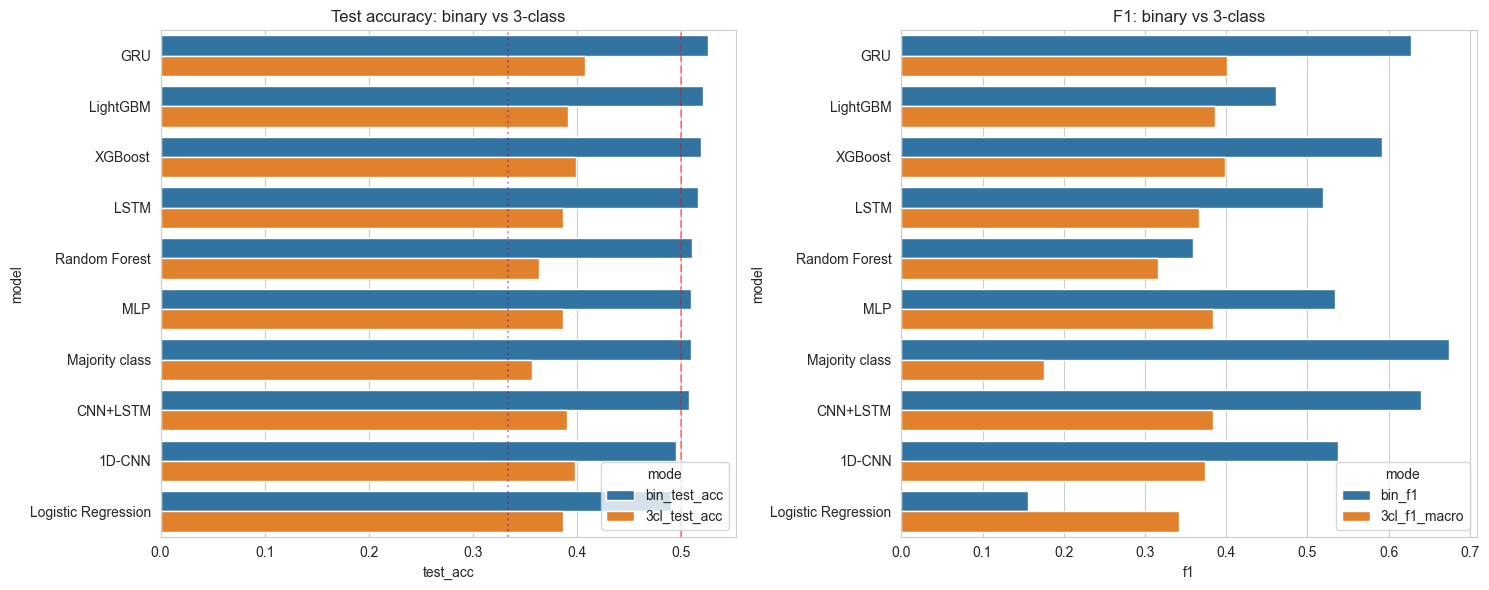

In [61]:
common = sorted(set(results_bin_df["model"]) & set(results_3_df["model"]))
comp = pd.DataFrame({"model": common})
comp["bin_test_acc"] = comp["model"].map(results_bin_df.set_index("model")["test_acc"])
comp["3cl_test_acc"] = comp["model"].map(results_3_df.set_index("model")["test_acc"])
comp["bin_f1"]       = comp["model"].map(results_bin_df.set_index("model")["f1"])
comp["3cl_f1_macro"] = comp["model"].map(results_3_df.set_index("model")["f1_macro"])
comp = comp.sort_values("bin_test_acc", ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
ma = comp.melt(id_vars="model", value_vars=["bin_test_acc","3cl_test_acc"], var_name="mode", value_name="test_acc")
sns.barplot(data=ma, x="test_acc", y="model", hue="mode", ax=axes[0])
axes[0].axvline(0.5, ls="--", c="red", alpha=0.4); axes[0].axvline(1/3, ls=":", c="purple", alpha=0.4)
axes[0].set_title("Test accuracy: binary vs 3-class")
mf = comp.melt(id_vars="model", value_vars=["bin_f1","3cl_f1_macro"], var_name="mode", value_name="f1")
sns.barplot(data=mf, x="f1", y="model", hue="mode", ax=axes[1]); axes[1].set_title("F1: binary vs 3-class")
plt.tight_layout(); plt.savefig(ARTIFACTS / "binary_vs_3class.png", dpi=120, bbox_inches="tight"); plt.show()

In [62]:
for name, p in predictions_bin.items():
    n_ref = len(p["y_pred"])
    msg = "OK" if len(p["y_return"]) == n_ref else f"MISMATCH y_return={len(p['y_return'])}"
    print(f"{name:25s}  n={n_ref:>6d}  {msg}")

Majority class             n= 47274  OK
Logistic Regression        n= 47274  OK
Random Forest              n= 47274  OK
XGBoost                    n= 47274  OK
LightGBM                   n= 47274  OK
MLP                        n= 47274  OK
1D-CNN                     n= 43654  OK
GRU                        n= 43654  OK
LSTM                       n= 43654  OK
CNN+LSTM                   n= 43654  OK


## 18. Bewaar beste model per StockType

Voor elke `StockType` (EQUITY, INDEX, ETF, ...) wordt het binary model met de
hoogste gemiddelde test accuracy gerangschikt en opgeslagen in
`models/<stock_type>/`. Bestaande modellen worden alleen overschreven als het
nieuwe model strict beter scoort (volgens `best.json` metadata).

In [63]:
# ---- Laad helpers ----
import importlib.util
def _load(name, file):
    spec = importlib.util.spec_from_file_location(name, str(file))
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod
sbm = _load("save_best_models",
            PROJECT_ROOT / "model" / "comparison" / "save_best_models.py")
pnl = _load("pnl_analysis",
            PROJECT_ROOT / "model" / "comparison" / "pnl_analysis.py")

MODELS_DIR = PROJECT_ROOT / "models"
print(f"trained_models: {len(trained_models)} verzameld -> {list(trained_models.keys())}")

# ---- Stap 1: P&L stats per (model, stock_type) berekenen voor binary ----
POSITION_SIZE_EUR = 1000.0   # vast bedrag per trade voor de € visual
pnl_table = pnl.compute_trade_stats_per_type(
    predictions_bin, market_df,
    position_size=POSITION_SIZE_EUR, mode="binary",
)
print(f"\n=== P&L ranking per stock type (long-only, €{POSITION_SIZE_EUR:.0f}/trade) ===")
print(pnl_table.sort_values(["stock_type", "net_pnl"], ascending=[True, False])
      .round(3).to_string(index=False))
pnl_table.to_csv(ARTIFACTS / "pnl_ranking_binary.csv", index=False)

# Voor het bewaren in best_pnl.json: per stock_type {model: stats_jsonable}
pnl_stats_for_save = {}
for model_name, p in predictions_bin.items():
    if not isinstance(p, dict) or "y_return" not in p: continue
    dfp = pd.DataFrame({"stock_id": p["stock_id"], "y_true": p["y_true"],
                        "y_pred": p["y_pred"], "y_return": p["y_return"]})
    type_map_local = market_df.groupby("stock_id")["StockType"].first().to_dict()
    dfp["stock_type"] = dfp["stock_id"].map(type_map_local).fillna("UNKNOWN")
    for stype, grp in dfp.groupby("stock_type"):
        s = pnl.compute_trade_stats(
            grp["y_true"].values, grp["y_pred"].values, grp["y_return"].values,
            position_size=POSITION_SIZE_EUR, mode="binary",
        )
        pnl_stats_for_save.setdefault(stype, {})[model_name] = pnl.stats_to_jsonable(s)

# ---- Stap 2: bewaren met alle inferentie-artefacten ----
saved = sbm.save_best_per_type(
    predictions=predictions_bin,
    trained_models=trained_models,
    market_df=market_df,
    models_dir=MODELS_DIR,
    notebook_version="V3-binary",
    scaler=scaler,
    feature_cols=FEATURE_COLS,      # tabular features zonder stk_dummies
    stk_cols=stk_cols,              # one-hot stock encoding
    extra_meta={
        "horizon_days":        HORIZON,
        "threshold_neutral":   THRESHOLD_NEUTRAL,
        "position_size_eur":   POSITION_SIZE_EUR,
        "strategy":            "long-only on y_pred==1",
    },
    pnl_stats_per_type=pnl_stats_for_save,
    save_predictions_csv=True,
)
print(f"\nTotaal opgeslagen of behouden: {len(saved)} stock types -> {MODELS_DIR}")


trained_models: 10 verzameld -> ['Majority class', 'Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM', 'MLP', '1D-CNN', 'GRU', 'LSTM', 'CNN+LSTM']

=== P&L ranking per stock type (long-only, €1000/trade) ===
              model stock_type  nbr_trades  winning  losing  even  win_pct  gain_loss_ratio   total_gain  total_loss      net_pnl  avg_gain  avg_loss  avg_pnl_per_trade  best_trade  worst_trade
Logistic Regression     EQUITY        3051     1458    1243   350    0.478          865.460 17416517.958  -17156.476 17399361.482 11945.486   -13.802           5702.839   93636.222     -177.875
     Majority class     EQUITY       37690    19021   17664  1005    0.505           38.040 17760193.243 -433576.288 17326616.956   933.715   -24.546            459.714   93636.222     -989.439
      Random Forest     EQUITY        9315     4934    4096   285    0.530          275.109 17375007.459  -52430.199 17322577.260  3521.485   -12.800           1859.643   93636.222     -224.518
     

## 18b. Winst/Verlies analyse — antwoord op de vraag van de co-promotor

> *"Hoeveel winst maak je bij een goede voorspelling en hoeveel verlies bij een foute voorspelling?"*

Long-only simulatie op de **test set**: bij elke voorspelling `up` openen we een long-positie met vast bedrag (€1000). Bij `down` doen we niets.

* **% winning trades** is niet hetzelfde als accuracy: enkel trades waar het model `up` voorspelt tellen.
* **Gain/Loss ratio**: gemiddelde winst / gemiddeld verlies. > 1.0 betekent dat je gemiddelde winst groter is dan je gemiddeld verlies.
* Eén heel goede trade kan een verlieslatende reeks goedmaken — zichtbaar in *Gain of best trade* vs *Loss of worst trade*.



--- EQUITY  |  best model: LightGBM  |  n_trades=14168 ---


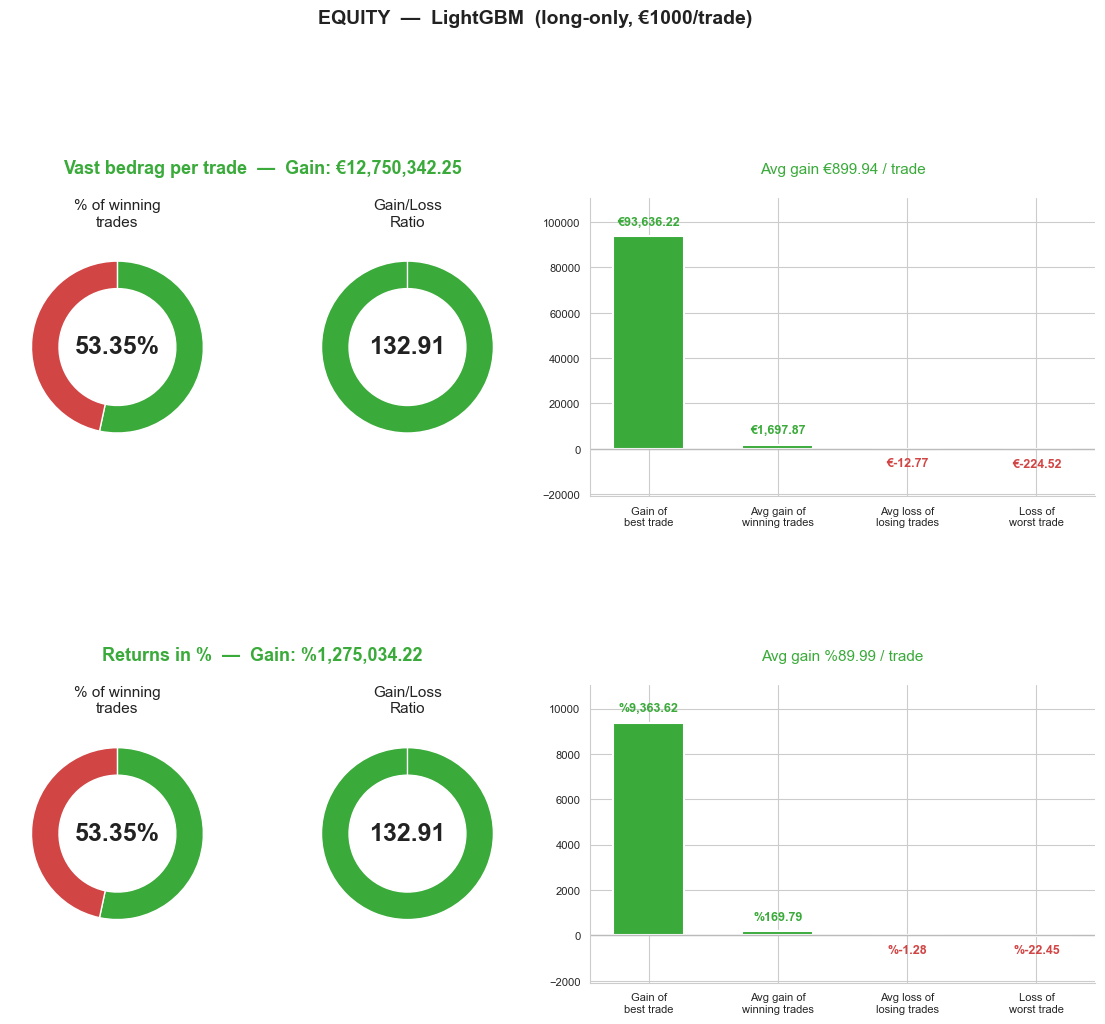

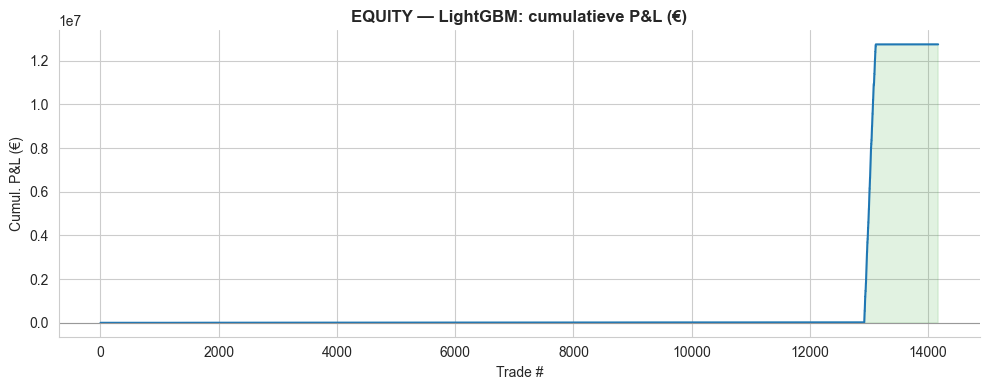


--- ETF  |  best model: GRU  |  n_trades=4593 ---


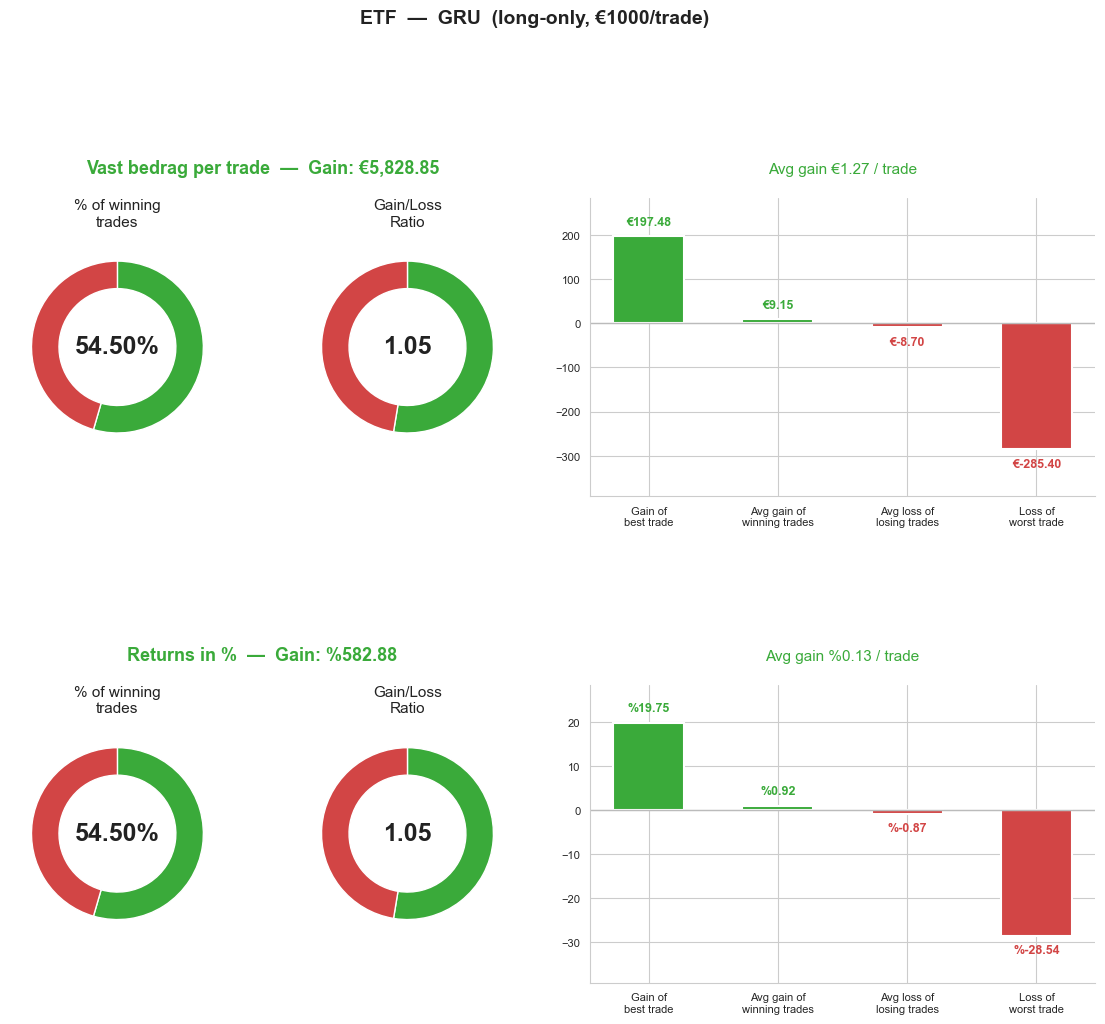

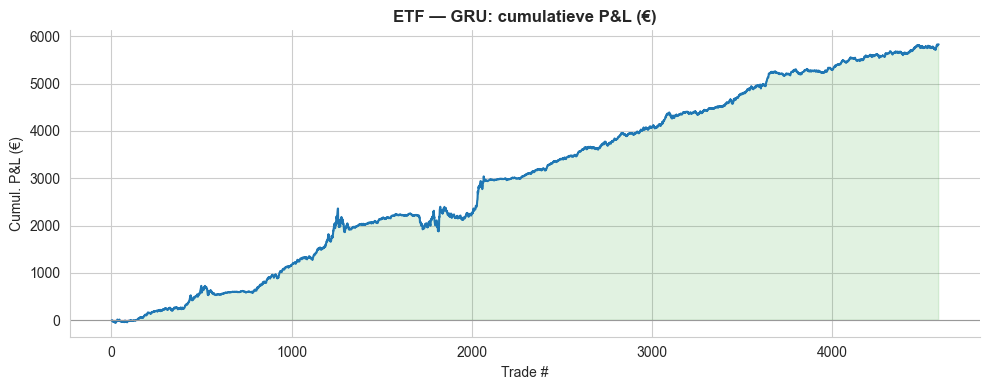


--- INDEX  |  best model: GRU  |  n_trades=2104 ---


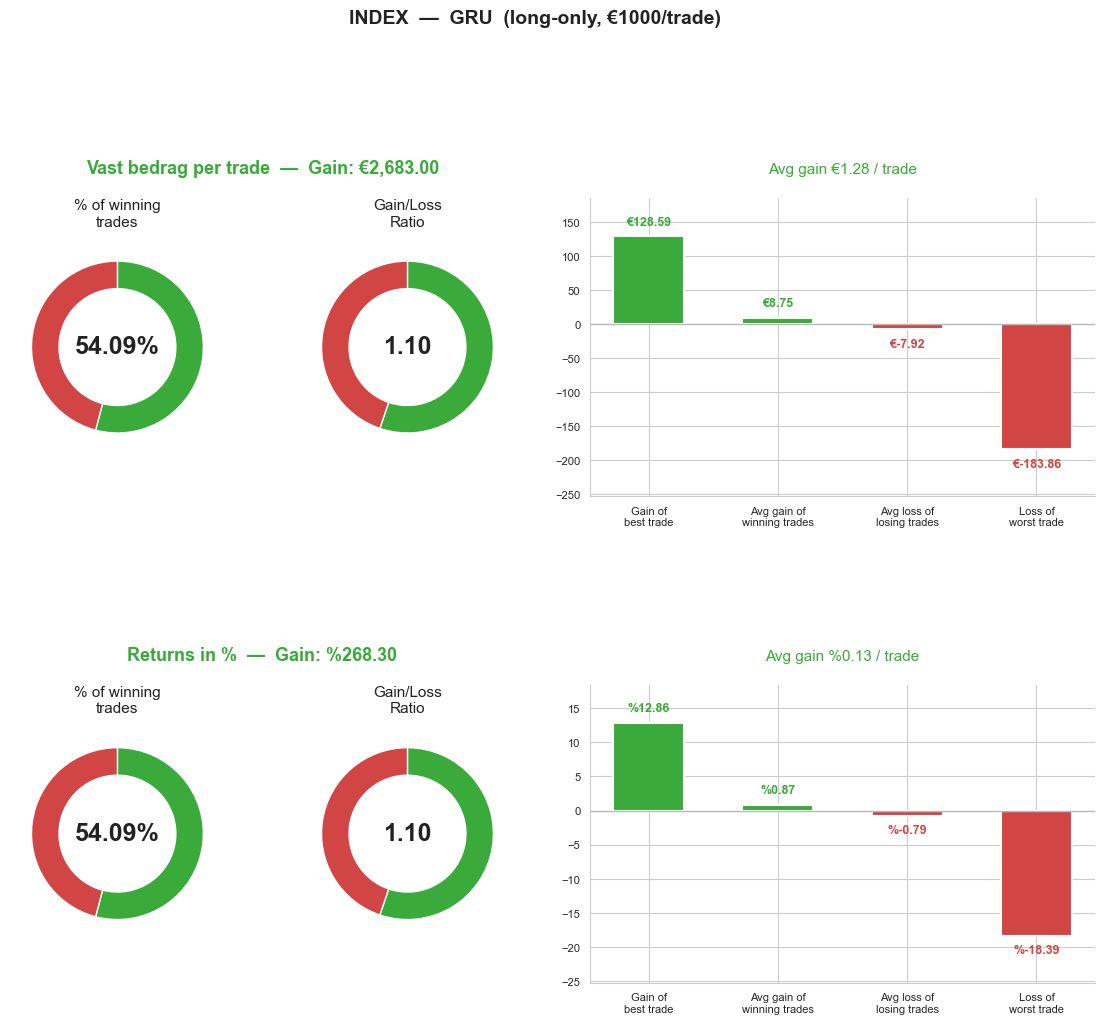

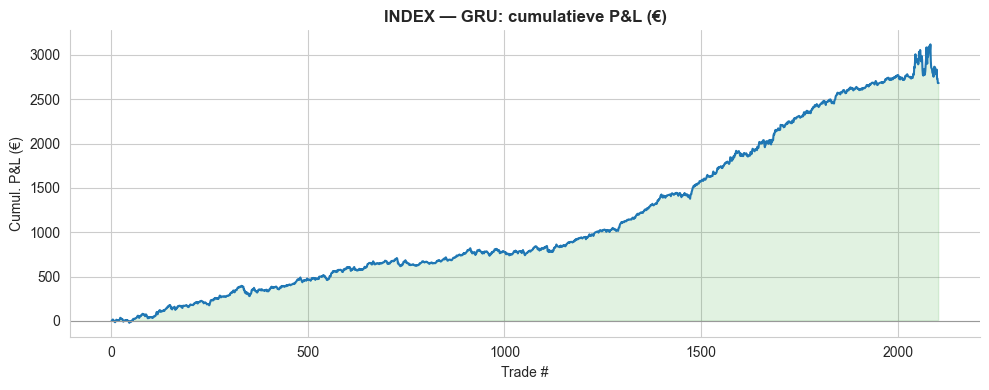

In [64]:
# Dashboard per stock type voor het BESTE model (zoals opgeslagen in models/<type>/best.json)
PNL_DIR = ARTIFACTS / "pnl"
PNL_DIR.mkdir(exist_ok=True, parents=True)

type_map_local = market_df.groupby("stock_id")["StockType"].first().to_dict()

for stype, meta in saved.items():
    winning_model = meta["model_name"]
    p = predictions_bin.get(winning_model)
    if p is None or "y_return" not in p:
        print(f"  [{stype}] geen y_return voor {winning_model}, skip")
        continue
    dfp = pd.DataFrame({
        "stock_id": p["stock_id"], "y_true": p["y_true"],
        "y_pred":   p["y_pred"],   "y_return": p["y_return"],
    })
    dfp = dfp[dfp["stock_id"].map(type_map_local).fillna("UNKNOWN") == stype]
    if dfp.empty:
        print(f"  [{stype}] geen rijen, skip"); continue

    stats_eur = pnl.compute_trade_stats(
        dfp["y_true"].values, dfp["y_pred"].values, dfp["y_return"].values,
        position_size=POSITION_SIZE_EUR, mode="binary",
    )
    stats_pct = pnl.compute_trade_stats(
        dfp["y_true"].values, dfp["y_pred"].values, dfp["y_return"].values,
        position_size=100.0,  # zo wordt y_return*100 → % per trade
        mode="binary",
    )

    print(f"\n--- {stype}  |  best model: {winning_model}  |  n_trades={stats_eur['nbr_trades']} ---")
    pnl.plot_pnl_dashboard_dual(
        stats_eur, stats_pct,
        title=f"{stype}  —  {winning_model}  (long-only, €{POSITION_SIZE_EUR:.0f}/trade)",
        save_path=PNL_DIR / f"{stype}_{winning_model}_dashboard.png",
    )
    pnl.plot_equity_curve(
        stats_eur, title=f"{stype} — {winning_model}: cumulatieve P&L (€)",
        save_path=PNL_DIR / f"{stype}_{winning_model}_equity.png",
    )


In [69]:
# %% Check: hoeveel % van y_pred = 1 per model (binary)
print("=" * 70)
print("PREDICTION DISTRIBUTION CHECK (Binary)")
print("=" * 70)
print(f"{'Model':<25s} {'% pred=1':>10s} {'% actual=1':>12s} {'verdict':>20s}")
print("-" * 70)

rows = []
for name, p in predictions_bin.items():
    y_pred = np.asarray(p["y_pred"])
    y_true = np.asarray(p["y_true"])
    pct_up_pred = (y_pred == 1).mean() * 100
    pct_up_true = (y_true == 1).mean() * 100

    if pct_up_pred > 85:
        verdict = "⚠️  amper voorspellend"
    elif pct_up_pred < 15:
        verdict = "⚠️  amper voorspellend"
    elif abs(pct_up_pred - pct_up_true) < 2:
        verdict = "≈ base rate"
    else:
        verdict = "✓ differentieert"

    rows.append({
        "model": name,
        "pct_pred_up": pct_up_pred,
        "pct_actual_up": pct_up_true,
        "diff_vs_base": pct_up_pred - pct_up_true,
        "verdict": verdict,
    })
    print(f"{name:<25s} {pct_up_pred:>9.1f}% {pct_up_true:>11.1f}% {verdict:>20s}")

pred_dist_df = pd.DataFrame(rows).sort_values("pct_pred_up", ascending=False)
pred_dist_df.to_csv(ARTIFACTS / "prediction_distribution.csv", index=False)

# %% Per stock_type opsplitsen — vaak interessanter
print("\n" + "=" * 70)
print("PER STOCK TYPE — beste model per type")
print("=" * 70)

type_map_local = market_df.groupby("stock_id")["StockType"].first().to_dict()

for name, p in predictions_bin.items():
    dfp = pd.DataFrame({
        "stock_id": p["stock_id"],
        "y_true":   p["y_true"],
        "y_pred":   p["y_pred"],
    })
    dfp["stock_type"] = dfp["stock_id"].map(type_map_local).fillna("UNKNOWN")
    summary = dfp.groupby("stock_type").apply(lambda g: pd.Series({
        "n":            len(g),
        "pct_pred_up":  (g["y_pred"] == 1).mean() * 100,
        "pct_true_up":  (g["y_true"] == 1).mean() * 100,
    })).round(1)
    print(f"\n--- {name} ---")
    print(summary.to_string())

PREDICTION DISTRIBUTION CHECK (Binary)
Model                       % pred=1   % actual=1              verdict
----------------------------------------------------------------------
Majority class                100.0%        50.9% ⚠️  amper voorspellend
Logistic Regression             9.5%        50.9% ⚠️  amper voorspellend
Random Forest                  25.5%        50.9%     ✓ differentieert
XGBoost                        66.8%        50.9%     ✓ differentieert
LightGBM                       38.1%        50.9%     ✓ differentieert
MLP                            54.4%        50.9%     ✓ differentieert
1D-CNN                         58.3%        50.8%     ✓ differentieert
GRU                            76.5%        50.8%     ✓ differentieert
LSTM                           49.9%        50.8%          ≈ base rate
CNN+LSTM                       86.0%        50.8% ⚠️  amper voorspellend

PER STOCK TYPE — beste model per type

--- Majority class ---
                  n  pct_pred_up  pct_tr

In [71]:
# %% Welk model heeft de beste win-rate op de trades die het neemt?
print("=" * 90)
print("PRECISION-FOCUSED: van de trades die het model neemt, hoeveel zijn winnaars?")
print("=" * 90)
print(f"{'Model':<22s} {'StockType':<10s} {'n_trades':>9s} {'pct_traded':>11s} "
      f"{'win_rate':>10s} {'edge_vs_base':>13s}")
print("-" * 90)

type_map_local = market_df.groupby("stock_id")["StockType"].first().to_dict()

rows = []
for name, p in predictions_bin.items():
    if name == "Majority class":
        continue
    dfp = pd.DataFrame({
        "stock_id": p["stock_id"],
        "y_true":   p["y_true"],
        "y_pred":   p["y_pred"],
        "y_return": p["y_return"],
    })
    dfp["stock_type"] = dfp["stock_id"].map(type_map_local).fillna("UNKNOWN")

    for stype, g in dfp.groupby("stock_type"):
        trades = g[g["y_pred"] == 1]
        n_trades = len(trades)
        if n_trades == 0:
            continue
        pct_traded = n_trades / len(g) * 100
        win_rate = (trades["y_true"] == 1).mean() * 100
        base_rate = (g["y_true"] == 1).mean() * 100
        edge = win_rate - base_rate
        avg_return_when_long = trades["y_return"].mean() * 100  # in %
        rows.append({
            "model": name, "stock_type": stype, "n_trades": n_trades,
            "pct_traded": pct_traded, "win_rate": win_rate,
            "base_rate": base_rate, "edge_pct_points": edge,
            "avg_return_pct": avg_return_when_long,
        })
        flag = " ★" if edge > 2 else ("  " if edge > 0 else " ✗")
        print(f"{name:<22s} {stype:<10s} {n_trades:>9d} {pct_traded:>10.1f}% "
              f"{win_rate:>9.1f}% {edge:>+12.1f}pp{flag}")

precision_df = pd.DataFrame(rows)
precision_df.to_csv(ARTIFACTS / "precision_per_model_type.csv", index=False)

print("\nLegend: ★ = edge > 2 percentage points  |  ✗ = slechter dan base rate")

PRECISION-FOCUSED: van de trades die het model neemt, hoeveel zijn winnaars?
Model                  StockType   n_trades  pct_traded   win_rate  edge_vs_base
------------------------------------------------------------------------------------------
Logistic Regression    EQUITY          3051        8.1%      47.8%         -2.7pp ✗
Logistic Regression    ETF             1257       19.5%      54.4%         +1.5pp  
Logistic Regression    INDEX            199        6.4%      43.7%         -8.3pp ✗
Random Forest          EQUITY          9315       24.7%      53.0%         +2.5pp ★
Random Forest          ETF             1814       28.1%      56.0%         +3.1pp ★
Random Forest          INDEX            922       29.5%      57.0%         +5.0pp ★
XGBoost                EQUITY         25106       66.6%      51.5%         +1.1pp  
XGBoost                ETF             4352       67.4%      54.7%         +1.9pp  
XGBoost                INDEX           2130       68.2%      53.2%         +1.2

In [72]:
# %% Net P&L met realistische transactiekosten per model
print("=" * 95)
print("NET P&L per model (met transactiekosten)")
print("=" * 95)

COSTS_TO_TEST = [0.0, 0.0005, 0.0015, 0.0030]  # 0bp, 5bp, 15bp, 30bp round-trip
POSITION_SIZE = 1000.0

type_map_local = market_df.groupby("stock_id")["StockType"].first().to_dict()

rows = []
for name, p in predictions_bin.items():
    if name == "Majority class":
        continue
    dfp = pd.DataFrame({
        "stock_id": p["stock_id"],
        "y_true":   p["y_true"],
        "y_pred":   p["y_pred"],
        "y_return": p["y_return"],
    })
    dfp["stock_type"] = dfp["stock_id"].map(type_map_local).fillna("UNKNOWN")

    for stype, g in dfp.groupby("stock_type"):
        trades = g[g["y_pred"] == 1]
        n = len(trades)
        if n == 0:
            continue
        gross_pnl = (trades["y_return"] * POSITION_SIZE).sum()
        row = {"model": name, "stock_type": stype, "n_trades": n,
               "gross_pnl": gross_pnl}
        for cost in COSTS_TO_TEST:
            cost_total = cost * POSITION_SIZE * n
            net = gross_pnl - cost_total
            row[f"net_pnl_{int(cost*10000)}bp"] = net
        rows.append(row)

net_df = pd.DataFrame(rows)
print(net_df.round(0).to_string(index=False))
net_df.to_csv(ARTIFACTS / "net_pnl_with_costs.csv", index=False)

# Highlight: welke modellen overleven

NET P&L per model (met transactiekosten)
              model stock_type  n_trades  gross_pnl  net_pnl_0bp  net_pnl_5bp  net_pnl_15bp  net_pnl_30bp
Logistic Regression     EQUITY      3051 17399361.0   17399361.0   17397836.0    17394785.0    17390208.0
Logistic Regression        ETF      1257     2117.0       2117.0       1488.0         231.0       -1654.0
Logistic Regression      INDEX       199      444.0        444.0        345.0         146.0        -153.0
      Random Forest     EQUITY      9315 17322577.0   17322577.0   17317920.0    17308605.0    17294632.0
      Random Forest        ETF      1814     3559.0       3559.0       2652.0         838.0       -1883.0
      Random Forest      INDEX       922     1872.0       1872.0       1411.0         489.0        -894.0
            XGBoost     EQUITY     25106 12995432.0   12995432.0   12982879.0    12957773.0    12920114.0
            XGBoost        ETF      4352     4140.0       4140.0       1964.0       -2388.0       -8916.0
     

In [68]:
import pandas as pd
dates = pd.to_datetime(predictions_bin["GRU"]["Date"])
print(f"Test periode: {dates.min().date()} → {dates.max().date()}  ({dates.nunique()} handelsdagen)")

Test periode: 2025-05-21 → 2026-05-22  (262 handelsdagen)


In [65]:
# Korte ranking per stock type: welke modellen zouden het meest winstgevend zijn?
for stype, grp in pnl_table.groupby("stock_type"):
    print(f"\n=== {stype} ===")
    cols = ["model","nbr_trades","winning","losing","win_pct",
            "gain_loss_ratio","net_pnl","avg_pnl_per_trade",
            "best_trade","worst_trade"]
    print(grp[cols].sort_values("net_pnl", ascending=False).round(3).to_string(index=False))



=== EQUITY ===
              model  nbr_trades  winning  losing  win_pct  gain_loss_ratio      net_pnl  avg_pnl_per_trade  best_trade  worst_trade
Logistic Regression        3051     1458    1243    0.478          865.460 17399361.482           5702.839   93636.222     -177.875
     Majority class       37690    19021   17664    0.505           38.040 17326616.956            459.714   93636.222     -989.439
      Random Forest        9315     4934    4096    0.530          275.109 17322577.260           1859.643   93636.222     -224.518
           CNN+LSTM       29962    15125   13981    0.505           76.853 16772180.065            559.782   93636.222     -989.336
                GRU       26709    13797   12236    0.517           83.944 16172753.453            605.517   93636.222     -989.336
               LSTM       17273     8944    7728    0.518          129.374 15991514.773            925.810   93636.222     -989.336
                MLP       20451    10448    9623    0.511   

In [66]:
ul = df[df["stock_id"] == "Unilever PLC"].sort_values("Date")[["Date","Close","High","Low"]]
print(ul.head(5)); print("..."); print(ul.tail(5))
# en specifiek rond de boundary:
print(ul[(ul["Date"] >= "2020-11-25") & (ul["Date"] <= "2020-12-30")])

             Date      Close       High        Low
397096 2016-01-04  3006.0764  3090.2593  2992.2236
397097 2016-01-05  3037.5127  3041.7751  2981.0356
397098 2016-01-06  3002.8796  3030.5854  2968.2474
397099 2016-01-07  2975.1743  2986.3631  2921.3612
397100 2016-01-08  2960.7881  2998.0845  2959.7226
...
             Date    Close     High      Low
401096 2026-05-06  4366.50  4385.00  4309.50
401098 2026-05-07    50.16    50.89    50.04
401100 2026-05-08  4274.50  4317.00  4242.00
401106 2026-05-11  4183.50  4255.00  4161.00
401108 2026-05-12  4217.00  4228.50  4176.00
             Date      Close       High        Low
398336 2020-11-25  4867.2700  4881.1459  4613.2326
398337 2020-11-26  4890.7529  4966.6899  4834.1816
398338 2020-11-27  4895.0234  4931.3148  4810.7004
398339 2020-11-30  4879.0112  4980.4129  4826.7095
398340 2020-12-01  4732.7788  4904.6277  4728.5093
398341 2020-12-02  4695.4224  4781.8805  4666.6028
398342 2020-12-03  4571.6060  4744.5221  4563.0669
398343 2020-

In [67]:
# 1. Wat zijn de extreme returns?
print(df["y_return"].describe(percentiles=[.001, .01, .5, .99, .999]))

# 2. Top 10 grootste returns - klikbaar bewijs
top = df.nlargest(10, "y_return")[["stock_id","Date","Close","y_return"]]
print("\nTOP 10 RETURNS:")
print(top.to_string(index=False))

# 3. Welke stocks zijn de schuldigen?
worst_offenders = (df.groupby("stock_id")["y_return"]
                    .agg(['max','min','count'])
                    .sort_values('max', ascending=False).head(10))
print("\nWORST OFFENDERS (max return per stock):")
print(worst_offenders)

# 4. Welke Close-waarden zijn verdacht laag?
low_close = df.nsmallest(10, "Close")[["stock_id","Date","Close"]]
print("\nLAAGSTE CLOSE WAARDEN:")
print(low_close.to_string(index=False))

count    466130.000000
mean          0.147578
std           3.832140
min          -0.991530
0.1%         -0.989320
1%           -0.066238
50%           0.000605
99%           0.070539
99.9%        94.173125
max         117.007839
Name: y_return, dtype: float64

TOP 10 RETURNS:
    stock_id       Date   Close   y_return
Unilever PLC 2020-12-21 38.8303 117.007839
Unilever PLC 2020-12-10 39.8330 116.770489
Unilever PLC 2020-12-22 39.3606 116.746719
Unilever PLC 2020-12-14 39.6466 116.462673
Unilever PLC 2020-12-18 39.7128 115.863716
Unilever PLC 2020-12-29 40.8151 115.662684
Unilever PLC 2021-01-06 40.8731 115.653848
Unilever PLC 2020-12-15 39.3772 115.612804
Unilever PLC 2020-12-16 40.1935 115.342381
Unilever PLC 2020-12-17 39.7792 115.185657

WORST OFFENDERS (max return per stock):
                                         max       min  count
stock_id                                                     
Unilever PLC                      117.007839 -0.991530   2640
AMC Entertainment Hold

## 19. Conclusie

V3 combineert vier dingen die V1/V2 niet hadden:

1. **LLM-based tweet -> stock impact scoring** koppelt elke tweet aan elke stock
   met een impact-score in [0,1]. Sentence-transformer met TF-IDF fallback.
2. **Stock-aware sentiment aggregatie**: tweet-sentiment wordt per stock
   gewogen met de impact-score ipv market-wide.
3. **isPresident feature + presidential boost**: tweets tijdens Trump's
   ambtstermijnen (20 jan 2017 - 20 jan 2021 en vanaf 20 jan 2025) krijgen
   2x meer gewicht in de aggregatie, en de datum-kolom `isPresident` is een
   extra feature voor alle modellen.
4. **Binary vs 3-class vergelijking** met alle 10 modellen in beide modes.

**Beste model per StockType** wordt aan het eind opgeslagen in
`models/<type>/` zodat je het direct kan laden voor inferentie. Cross-version
vergelijking: als V2 of V4 later een hoger scorend model produceert voor
dezelfde stock type, wordt het automatisch vervangen (via `best.json` check).